In [1]:
from src.measure_ir import *
import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.real_time import RealtimeFxLMS

In [2]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(fs)

In [3]:
error_ir, _ = measure_ir(ad)
error_ir_stream, _ = measure_ir_stream(ad, block_size=64)

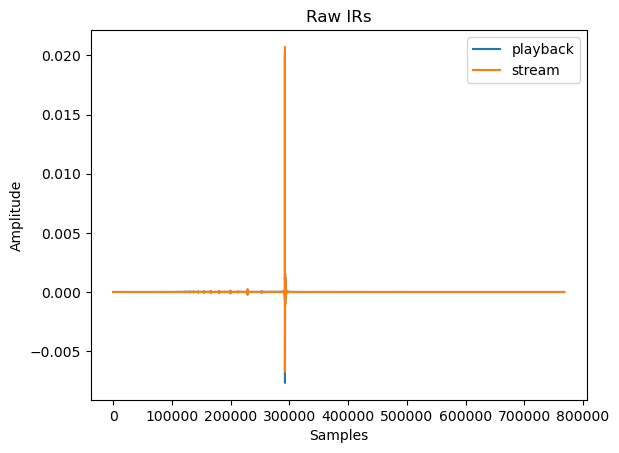

In [4]:
plt.plot(error_ir, label="playback")
plt.plot(error_ir_stream, label="stream")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Raw IRs')
plt.legend()
plt.show()

In [5]:
ir_len = 128
panel_to_err_cm = 9
filter_order = 2 * ir_len

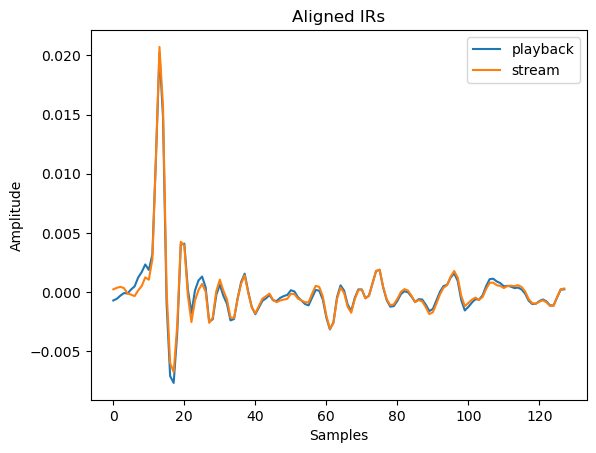

In [6]:
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)
panel_ir_stream = align_ir_by_distance(error_ir_stream, panel_to_err_cm, ir_len)

plt.plot(panel_ir, label="playback")
plt.plot(panel_ir_stream, label="stream")

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IRs')
plt.legend()
plt.show()

In [7]:
arthur_repeated = np.tile(arthur, 1)
arthur.shape, arthur_repeated.shape

((238834,), (238834,))

In [8]:
rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=64,
    filter_order=filter_order,
)
error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)

In [9]:
lag = rt.empirical_delay()

Lag from cross-correlation: 4470
Delay from device: 4312


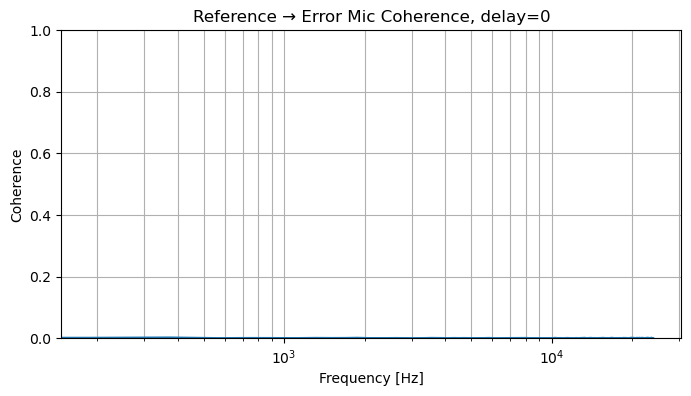

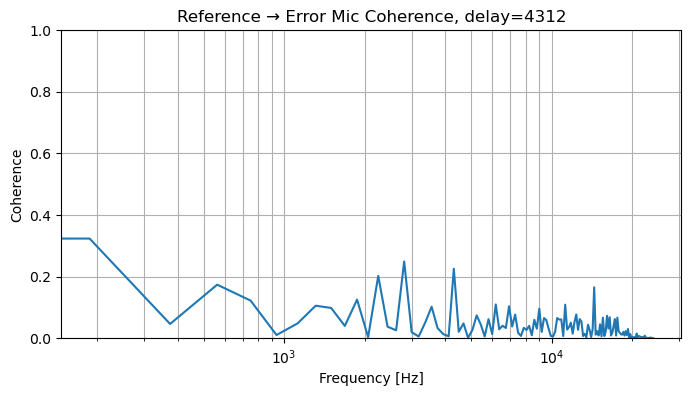

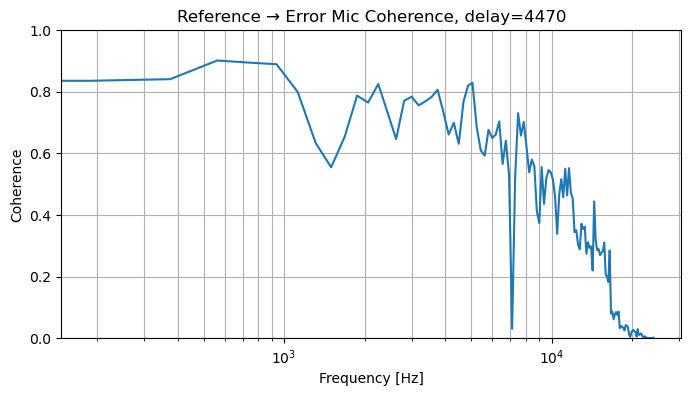

In [10]:
rt.plot_coherence(delay=0)
rt.plot_coherence(delay=4312)
rt.plot_coherence(delay=lag)


In [11]:
arthur_repeated = np.tile(arthur, 10)
arthur.shape, arthur_repeated.shape
rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=64,
    filter_order=filter_order,
)
error_nc, cancel_nc, *_ = rt.run(source_gain=1.0, cancel_gain=0.0)
lag = rt.empirical_delay()

Lag from cross-correlation: 4476
Delay from device: 4312


In [12]:
# rt.reset(lag=0)
# error, cancel, w_norms, title_ext = rt.run(
#     source_gain=1.0, 
#     cancel_gain=.1,
#     fx=True,
#     nlms=True,
#     clean_source=True,
#     step_fn=1e-4,
#     leak=3e-7,
#     max_norm=1.0,
# )

# rt.all_plots(error_nc)

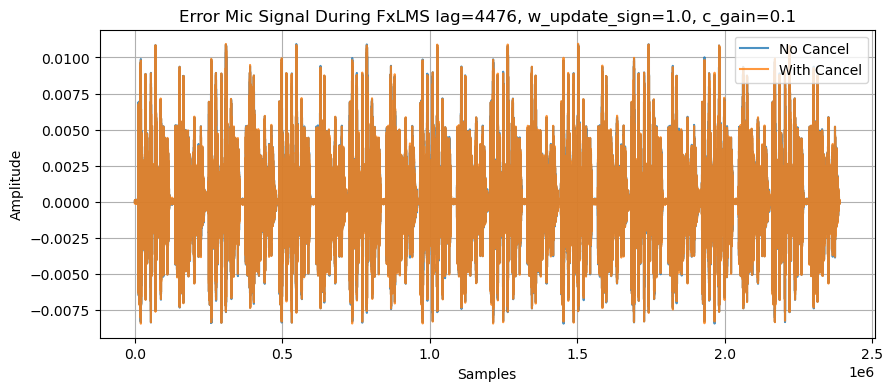

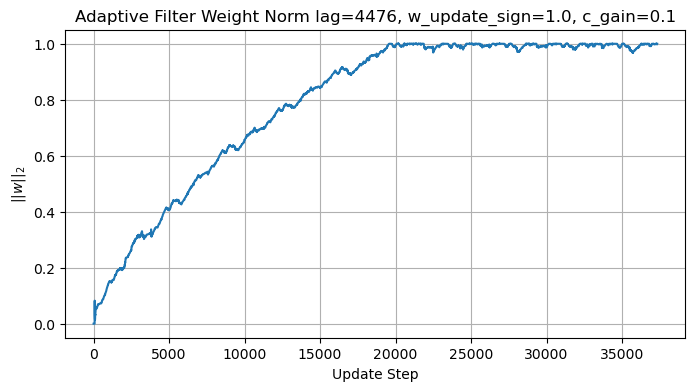

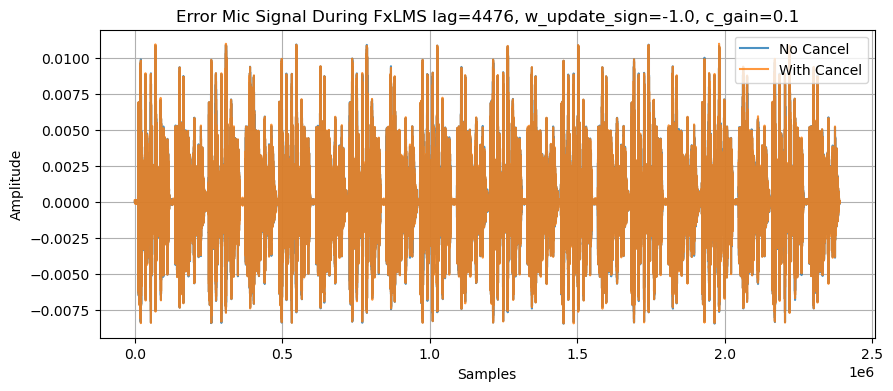

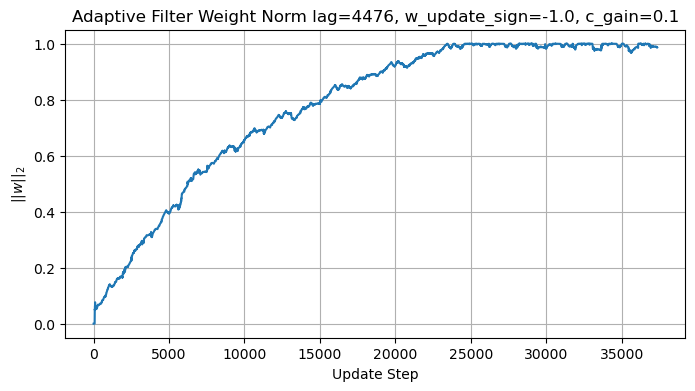

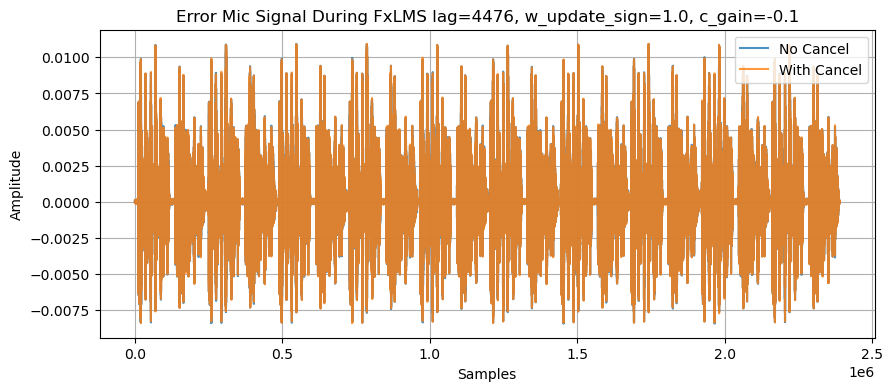

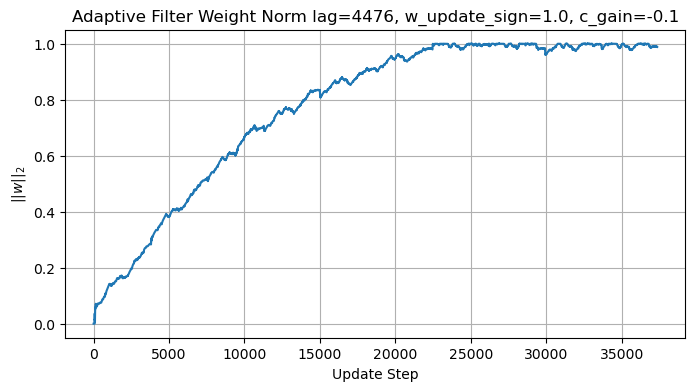

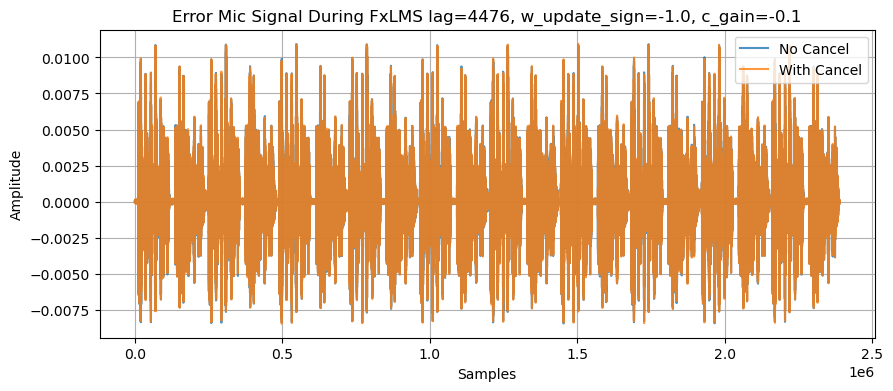

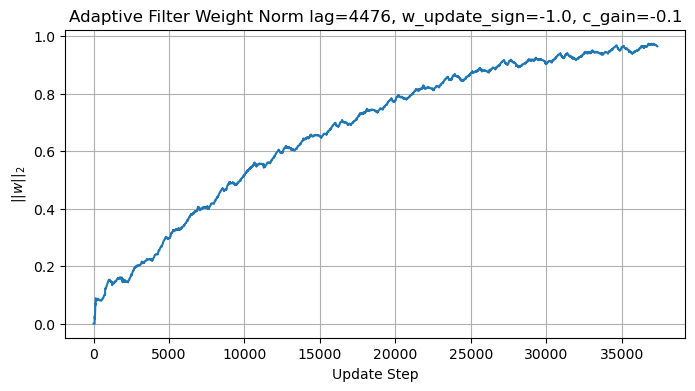

In [15]:
c_gains = [.1, -.1]
signs = [1.0, -1.0]

for c_gain in c_gains:
    for sign in signs:
        rt.reset(lag)
        error, cancel, w_norms, title_ext = rt.run(
            source_gain=1.0, 
            cancel_gain=c_gain,
            w_update_sign=sign,
            fx=True,
            nlms=True,
            clean_source=True,
            step_fn=1e-3,
            leak=1e-6,
            max_norm=1.0,
        )
        title_ext = f'lag={lag}, w_update_sign={sign}, c_gain={c_gain}'
        rt.plot_error_mic(error_nc, title_ext)
        rt.plot_w_norm(title_ext)